In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import torch
print(torch.cuda.is_available())

# for RTX 5080
## """pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128"""

import numpy as np
import librosa
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from panns_inference import AudioTagging

# --- 1. Configuration ---
DATA_DIR = r"C:\programming\ml\datasets\IRMAS-TrainingData" 
TEST_DIR = r"C:\programming\ml\datasets\IRMAS-TestingData"
BATCH_SIZE = 32
IMG_SHAPE = (128, 130, 1)
PRED_THRESHOLD = 0.20

instrument_list = ['cel', 'cla', 'flu', 'gac', 'gel', 'org', 'pia', 'sax', 'tru', 'vio', 'voi']
label_map = {inst: i for i, inst in enumerate(instrument_list)}
NUM_CLASSES = len(instrument_list)

instrument_map = {
    'cel': 'Celesta',         'cla': 'Clarinet',        'flu': 'Flute',
    'gac': 'Acoustic Guitar', 'gel': 'Electric Guitar', 'org': 'Organ',
    'pia': 'Piano',           'sax': 'Saxophone',       'tru': 'Trumpet',
    'vio': 'Violin',          'voi': 'Human Voice'
}

True


In [2]:
# --- 2. File Discovery ---
file_paths = []
labels = []

for root, dirs, files in os.walk(DATA_DIR):
    folder_name = os.path.basename(root)
    if folder_name in label_map:
        idx = label_map[folder_name]
        for file in files:
            if file.endswith(".wav"):
                file_paths.append(os.path.join(root, file))
                # Change: labels are float32 vectors of shape (11,), each position represents one instrument (0.0 or 1.0)
                label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
                label_vec[idx] = 1.0
                labels.append(label_vec)

labels = np.array(labels, dtype=np.float32)  # Change: shape (N, 11) instead of (N,)
print(f"Found {len(file_paths)} training files")

# Split training data to train/val
# Change: stratify uses argmax because labels are now vectors
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42,
    stratify=np.argmax(labels, axis=1)
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# Compute weights (Added in v4)
# Convert one-hot to integer labels for weight computation
train_labels_int = np.argmax(train_labels, axis=1)
classes = np.unique(train_labels_int)
weights = compute_class_weight('balanced', classes=classes, y=train_labels_int)
class_weight_dict = dict(enumerate(weights))

print("Class weights:", class_weight_dict)

Found 6705 training files
Train: 5364 | Val: 1341
Class weights: {0: np.float64(1.5730205278592375), 1: np.float64(1.207020702070207), 2: np.float64(1.3507932510702594), 3: np.float64(0.9561497326203209), 4: np.float64(0.8020334928229665), 5: np.float64(0.8931068931068931), 6: np.float64(0.8451236804789665), 7: np.float64(0.9733260751224823), 8: np.float64(1.0577795306645632), 9: np.float64(1.0509404388714734), 10: np.float64(0.7839812920198772)}


Custom SpecAugment layer to augment our data. Mimics real-world edge cases. The augmentation policy consists of warping the features, masking blocks of frequency channels, and masking blocks of time steps.

In [3]:
import torch.nn as nn

@keras.saving.register_keras_serializable()
class SimpleSpecAugment(nn.Module):
    """PyTorch-native SpecAugment for use with Keras+Torch backend."""
    
    def __init__(self, time_masks=3, freq_masks=3, time_mask_param=50, 
                 freq_mask_param=25, noise_std=0.01):
        super().__init__()
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        
    def forward(self, inputs, training=True):
        if not training:
            return inputs
            
        # inputs shape: (batch, height, width, channels)
        result = inputs.clone()
        batch_size, h, w, c = result.shape

        # Add Gaussian noise
        if self.noise_std > 0:
            noise = torch.randn_like(result) * self.noise_std
            result = result + noise
        
        # Frequency masking (along height dimension)
        for _ in range(self.freq_masks):
            # Random mask size and position for each batch item
            mask_size = torch.randint(0, self.freq_mask_param, (1,)).item()
            if mask_size >= h:
                continue
                
            mask_start = torch.randint(0, h - mask_size, (1,)).item()
            
            # Apply mask
            result[:, mask_start:mask_start + mask_size, :, :] = 0
        
        # Time masking (along width dimension)
        for _ in range(self.time_masks):
            mask_size = torch.randint(0, self.time_mask_param, (1,)).item()
            if mask_size >= w:
                continue
                
            mask_start = torch.randint(0, w - mask_size, (1,)).item()
            
            # Apply mask
            result[:, :, mask_start:mask_start + mask_size, :] = 0
            
        return result
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        return {
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        }

Wrapper to enable sequential Keras model use with SpecAug.

In [4]:
@keras.saving.register_keras_serializable()
class SpecAugmentWrapper(tf.keras.layers.Layer):
    """Wrapper that applies SpecAugment using PyTorch operations."""
    
    def __init__(self, time_masks=2, freq_masks=2, time_mask_param=40, freq_mask_param=20, noise_std=0.01, **kwargs):
        super().__init__(**kwargs)
        self.time_masks = time_masks
        self.freq_masks = freq_masks
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param
        self.noise_std = noise_std
        # Create the PyTorch module
        self.specaugment = SimpleSpecAugment(
            time_masks, freq_masks, time_mask_param, freq_mask_param, noise_std
        )
    
    def call(self, inputs, training=None):
        if training:
            # Apply SpecAugment
            return self.specaugment(inputs, training=True)
        return inputs
    
    def get_config(self):
        """Returns the configuration of the layer for serialization."""
        config = super().get_config()
        config.update({
            'time_masks': self.time_masks,
            'freq_masks': self.freq_masks,
            'time_mask_param': self.time_mask_param,
            'freq_mask_param': self.freq_mask_param,
            'noise_std': self.noise_std,
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        """Creates the layer from its configuration."""
        return cls(**config)

In [5]:
@keras.saving.register_keras_serializable()
class ConcatenatedPooling(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.avg_pool = tf.keras.layers.GlobalAveragePooling2D()
        self.max_pool = tf.keras.layers.GlobalMaxPooling2D()
        self.concat = tf.keras.layers.Concatenate()
    
    def call(self, inputs):
        avg = self.avg_pool(inputs)
        max_pool = self.max_pool(inputs)
        return self.concat([avg, max_pool])
    
    def compute_output_shape(self, input_shape):
        # Returns (batch_size, channels * 2)
        return (input_shape[0], input_shape[-1] * 2)
    
    def get_config(self):
        config = super().get_config()
        return config
    
    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [6]:
# --- 1. Configuration (Updated for CNN14) ---
# CNN14 expects exactly 32kHz sample rate
WAVE_SHAPE = (96000,) # 3 seconds * 32000 sr = 96000 samples

# ... (Keep your dataset splitting and weights logic exactly the same) ...

# --- 2. Data Pipeline (Updated) ---
# Extracts raw 1D waveforms instead of spectrogram images
def process_audio(file_path, label):
    def _parse_audio(fp):
        fp = fp.numpy().decode('utf-8')
        
        # Load audio at 32kHz (CNN14's native sample rate)
        audio, _ = librosa.load(fp, sr=32000, duration=3.0)
        
        # Pad with zeros if shorter than 3 seconds
        target_length = 96000
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]
            
        return audio.astype(np.float32)

    [waveform,] = tf.py_function(_parse_audio, [file_path], [tf.float32])
    waveform.set_shape(WAVE_SHAPE) # 1D Array
    
    return waveform, label

# (make_dataset stays exactly the same)
def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(len(paths))
    ds = ds.map(process_audio, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels)
val_ds   = make_dataset(val_paths,   val_labels)

c:\programming\ml\Neural-Networks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# --- 3. The Model (Updated) ---

@keras.saving.register_keras_serializable()
class CNN14EmbeddingLayer(keras.layers.Layer):
    """Wraps the PyTorch CNN14 model inside a Keras 3 Layer"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Load pre-trained CNN14
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # AudioTagging automatically downloads the AudioSet weights
        self.at = AudioTagging(checkpoint_path=None, device=device)
        self.cnn14 = self.at.model
        
        # Freeze all CNN14 parameters so we act as a feature extractor
        for param in self.cnn14.parameters():
            param.requires_grad = False

    def call(self, inputs, training=False):
        # inputs shape: (batch_size, 96000)
        self.cnn14.eval() # Keep batchnorm and dropout frozen
        with torch.no_grad():
            # CNN14 outputs a dictionary. We want the 2048-dim 'embedding'
            output_dict = self.cnn14(inputs)
            
        return output_dict['embedding'] 
        
    def get_config(self):
        return super().get_config()

# Build the new Keras model
model = keras.Sequential([
    keras.Input(shape=WAVE_SHAPE),
    
    # Extracts the 2048-dimensional features using frozen CNN14
    CNN14EmbeddingLayer(),
    
    # Trainable classification head
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(NUM_CLASSES, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(multi_label=True, name='auc')]
)

model.summary()

# (Keep your EarlyStopping, ReduceLROnPlateau, and model.fit the exact same)

Checkpoint path: C:\Users\35840/panns_data/Cnn14_mAP=0.431.pth
GPU number: 1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn14_embedding_layer           │ (None, 2048)           │    81,837,071 │
│ (CNN14EmbeddingLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,022,362 (316.71 MB)

 Trainable params: 81,937,882 (312.57 MB)

 Non-trainable params: 1,084,480 (4.14 MB)

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Reduce learning rate if plateau (Added in v4)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.4, patience=5, min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    epochs=300,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/300
  1/168 ━━━━━━━━━━━━━━━━━━━━ 51s 308ms/step - accuracy: 0.0938 - auc: 0.4824 - loss: 1.1551

c:\programming\ml\Neural-Networks\.venv\Lib\site-packages\keras\src\optimizers\base_optimizer.py:862: UserWarning: Gradients do not exist for variables ['variable_3', 'variable_4', 'variable_5', 'variable_6', 'variable_7', 'variable_8', 'variable_9', 'variable_10', 'variable_11', 'variable_12', 'variable_13', 'variable_14', 'variable_15', 'variable_16', 'variable_17', 'variable_18', 'variable_19', 'variable_20', 'variable_21', 'variable_22', 'variable_23', 'variable_24', 'variable_25', 'variable_26', 'variable_27', 'variable_28', 'variable_29', 'variable_30', 'variable_31', 'variable_32', 'variable_33', 'variable_34', 'variable_35', 'variable_36', 'variable_37', 'variable_38', 'variable_39', 'variable_40', 'variable_41', 'variable_42', 'variable_43', 'variable_44'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


168/168 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy: 0.2256 - auc: 0.6440 - loss: 0.4169 - val_accuracy: 0.6592 - val_auc: 0.9250 - val_loss: 0.2720 - learning_rate: 5.0000e-04
Epoch 2/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 27s 156ms/step - accuracy: 0.3811 - auc: 0.7775 - loss: 0.2757 - val_accuracy: 0.6107 - val_auc: 0.9403 - val_loss: 0.2304 - learning_rate: 5.0000e-04
Epoch 3/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.4364 - auc: 0.8178 - loss: 0.2521 - val_accuracy: 0.6585 - val_auc: 0.9472 - val_loss: 0.2214 - learning_rate: 5.0000e-04
Epoch 4/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.4670 - auc: 0.8335 - loss: 0.2393 - val_accuracy: 0.6779 - val_auc: 0.9511 - val_loss: 0.2113 - learning_rate: 5.0000e-04
Epoch 5/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 26s 155ms/step - accuracy: 0.4903 - auc: 0.8496 - loss: 0.2271 - val_accuracy: 0.6413 - val_auc: 0.9528 - val_loss: 0.2179 - learning_rate: 5.0000e-04
Epoch 6/300
168/168 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/s

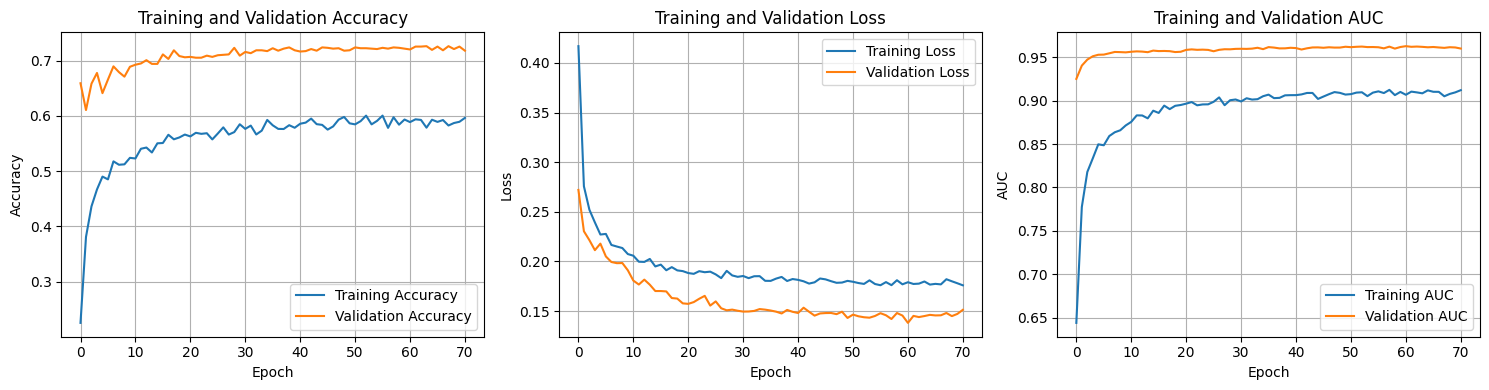

Best epoch: 61
Validation Accuracy: 0.7204
Validation Loss:     0.1381
Validation AUC:      0.9627
------------------------------
Training Accuracy:   0.5889
Training Loss:       0.1791


In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))  # Change: fit new AUC plot

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch');  plt.ylabel('Accuracy');  plt.legend();  plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch');  plt.ylabel('Loss');  plt.legend();  plt.grid(True)

# Change: added AUC plot = tracks how well the model ranks instruments overall (unaffected by the choice of threshold)
plt.subplot(1, 3, 3)
plt.plot(history.history['auc'],     label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('Training and Validation AUC')
plt.xlabel('Epoch');  plt.ylabel('AUC');  plt.legend();  plt.grid(True)

plt.tight_layout()
plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
print(f"Validation Loss:     {history.history['val_loss'][best_epoch]:.4f}")
print(f"Validation AUC:      {history.history['val_auc'][best_epoch]:.4f}")  # Change: added AUC
print("-" * 30)
print(f"Training Accuracy:   {history.history['accuracy'][best_epoch]:.4f}")
print(f"Training Loss:       {history.history['loss'][best_epoch]:.4f}")

In [10]:
from sklearn.metrics import f1_score

# (Added in v4)
def find_optimal_thresholds(y_true, y_pred_probs, val_data):
    """Find best threshold per class using validation set"""
    optimal_thresholds = []
    
    for i in range(NUM_CLASSES):
        best_f1 = 0
        best_thresh = 0.2  # default
        
        for thresh in np.arange(0.1, 0.6, 0.05):
            y_pred_binary = (y_pred_probs[:, i] > thresh).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_binary)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
                
        optimal_thresholds.append(best_thresh)
        print(f"{instrument_list[i]}: threshold={best_thresh:.3f}, F1={best_f1:.3f}")
    
    return optimal_thresholds

In [15]:
## THRESHOLD IS THE CONFIDENCE BAR WHICH DECIDES IF THERE IS AN X INSTRUMENT IN THE SAMPLE.
## WE HAVE 11 INSTRUMENTS SO RANDOM GUESSING WOULD BE AROUND 0.09.
## SO IF WE HAVE THRESHOLD OF 0.20 IT NEEDS TO HAVE ATLEAST 0.20 PROBABILITY TO BE FLAGGED
## THAT THE INSTRUMENT IS IN THE SAMPLE.

# Change: returns a probability vector (11,) instead of a single float for one instrument -> all instruments are evaluated in one pass per file
def predict_on_test_file(file_path, model):
    # Load at 32kHz
    audio, sr = librosa.load(file_path, sr=32000) 
    chunk_size = 96000  # 3 seconds at 32kHz
    chunk_probs = []

    # Slide a 3-second window across the audio file
    for i in range(0, len(audio) - chunk_size + 1, chunk_size):
        chunk = audio[i : i + chunk_size]
        inp = chunk[np.newaxis, :] # Add batch dimension -> (1, 96000)
        pred = model.predict(inp, verbose=0)
        chunk_probs.append(pred[0])

    # Handle files shorter than 3 seconds (or remaining tails)
    if not chunk_probs or len(audio) < chunk_size:
        # Just grab the beginning and pad it
        chunk = audio[:chunk_size]
        chunk = np.pad(chunk, (0, chunk_size - len(chunk)))
        inp = chunk[np.newaxis, :]
        pred = model.predict(inp, verbose=0)
        chunk_probs.append(pred[0])

    # Return the highest confidence found across all 3s windows
    return np.max(chunk_probs, axis=0)
    #return np.mean(chunk_probs, axis=0)

def predict_with_dynamic_threshold(file_path, model, thresholds):
    probs = predict_on_test_file(file_path, model)
    return (probs > thresholds).astype(int)

test_files = sorted([f for f in os.listdir(TEST_DIR) if f.endswith('.wav')])

# Change: y_true and y_pred_probs are now 2D arrays (num_files, 11) instead of 1D
y_true       = []
y_pred_probs = []
y_pred_binary = []

# Acquire optimal thresholds for instrument recog from validation set (Added in v4)
val_pred_probs = model.predict(val_ds)
optimal_thresholds = find_optimal_thresholds(val_labels, val_pred_probs, val_ds)

for f in test_files:
    file_path = os.path.join(TEST_DIR, f)
    txt_path  = os.path.splitext(file_path)[0] + '.txt'

    # Change: label is now a vector — all instruments mentioned in the .txt are flagged
    label_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    if os.path.exists(txt_path):
        with open(txt_path, 'r') as t:
            labels_in_file = [item.strip() for item in t.read().split()]
            for code in labels_in_file:
                if code in label_map:
                    label_vec[label_map[code]] = 1.0

    y_true.append(label_vec)
    y_pred_binary.append(predict_with_dynamic_threshold(file_path, model, thresholds=optimal_thresholds))

    # raw probabilities for AUC score
    probs = predict_on_test_file(file_path, model)
    y_pred_probs.append(probs)

y_true        = np.array(y_true)
y_pred_binary = np.array(y_pred_binary)

print(f"Evaluated {len(test_files)} test files")

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step
cel: threshold=0.300, F1=0.099
cla: threshold=0.100, F1=0.140
flu: threshold=0.100, F1=0.087
gac: threshold=0.100, F1=0.105
gel: threshold=0.100, F1=0.162
org: threshold=0.100, F1=0.158
pia: threshold=0.100, F1=0.175
sax: threshold=0.100, F1=0.158
tru: threshold=0.100, F1=0.086
vio: threshold=0.150, F1=0.094
voi: threshold=0.100, F1=0.157
Evaluated 2874 test files


In [16]:
# RECALL    = "Of all the X instruments in the test set, how many did the model actually find?"
# PRECISION = "When the model says it's a X instrument, how often is it actually a X instrument?"
# F1 SCORE  = harmonic mean of precision and recall "The balance of the two"

# Change: one report to cover all 11 instruments
print(f"Multilabel Classification Report (thresholds={optimal_thresholds}):\n")
print(classification_report(
    y_true,
    y_pred_binary,
    target_names=[instrument_map[k] for k in instrument_list]
))

Multilabel Classification Report (thresholds=[np.float64(0.30000000000000004), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.15000000000000002), np.float64(0.1)]):

                 precision    recall  f1-score   support

        Celesta       0.18      0.67      0.28       111
       Clarinet       0.07      0.77      0.12        62
          Flute       0.18      0.93      0.31       163
Acoustic Guitar       0.47      0.57      0.52       535
Electric Guitar       0.53      0.90      0.66       942
          Organ       0.33      0.64      0.43       361
          Piano       0.59      0.51      0.55       995
      Saxophone       0.42      0.95      0.58       326
        Trumpet       0.28      0.83      0.42       167
         Violin       0.47      0.73      0.57       211
    Human Voice       0.56      1.00      0.72      1044

      micro avg       0.41      0.78      0.54

In [17]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_true, y_pred_probs, average='macro')
print(f"Test AUC: {auc_score:.4f}")

Test AUC: 0.8648


In [18]:
model.save("irmas_instrument_classifier_v6_CNN.keras")
print("Model saved.")

Model saved.


# Project goal and motivation

The goal of this project was to create a neural network model that could recognize musical instruments from a music sample. The model takes an audio file as input and outputs, which of the 11 instruments from the IRMAS dataset are present in it. Detecting different instruments from audio is challenging because multiple instruments can play at the same time and the sounds can overlap. Detecting instruments from audio could be used for example in music education tools …

## Description of the data and preprocessing

The IRMAS (Instrument Recognition in Musical Audio Signals) dataset was used for the project. It includes 6705 excerpts for training and 2874 excerpts for testing. The instrument classes were cello, clarinet, flute, acoustic guitar, electric guitar, organ, piano, saxophone, trumpet, violin, and human singing voice. 

Audio files were loaded at sampling rate 22,050 Hz and were trimmed to 3 seconds. Files shorter than 3 seconds were padded by adding zeros to the end. A Mel spectrogram was computed with 128 frequency bins and converted to decibels. Values were then normalized to a 0–1 range using (spec_db + 80.0) / 80.0. The result is a (128, 130, 1) grayscale image. This was done because CNN works with images, so the audio needs to be converted into an image format first. 

Data was split into training and validation sets by using stratify splitting. It was used to ensure every instrument class is equally represented in both sets.

## Model Architecture

The model architecture went through several iterations. The first version used softmax activation and only classified if one particular instrument was detected. Later iterations switched to multilabel classification using sigmoid activation, which allowed the model to detect multiple instruments at once. 

(The most current version uses… ) CNN model and it takes the Mel spectrogram as input and processes it like a grayscale image. CNN was chosen because it finds patterns from images. For that reason the audio is first converted into Mel spectrogram using librosa.

The initial multilabel classification network model had two convolutional blocks. The first block was 32 filters and the second block had 64 filters. Increasing the filter count allows the model to detect a wider variety of patterns and this was done in later versions. After each block, MaxPooling was used to shrink the image so that the next layer has less data to process. BatchNormalization is used for keeping the training stable. 

Initial model used a Flatten() layer before the dense layers but this proved to be unwieldy as model parameter count exploded and it made training slow. Model performance was also hampered, since it caused overfitting and under-generalization. Using GlobalMaxPooling2D() was the next step, as this detects the biggest transients in the sound files and compresses model parameters significantly (lossy-compression: 128, 127, 1 is turned into 1, 1, 1). This already improved model generalization by a lot, but some instruments were being detected more reliably with MaxPooling and others not so. This necessitated the inclusion of GlobalMaxPooling2D() as well, to further capture instruments with long sustained sounds, like the woodwinds. This was achieved with a custom ConcatenatedPooling layer.

The final model we settled on was to have three convolutional blocks with 32-, 64- and 128 filters to capture different sizes of patterns. The dense network at the end was also expanded to include one more layer to help reconstruct possible lost temporal data during GlobalMaxPooling2D and GlobalAveragePooling2D.
